Will run on cuda


/home/charles/miniconda3/envs/gpvisc/lib/python3.11/site-packages/gpvisc/models.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_train_valid = torch.load(model_path /

Loading the viscosity datasets...


/home/charles/miniconda3/envs/gpvisc/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:284: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(



Training-Validation metrics

Model Performance Summary:
------------------------------------------------------------
Model                RMSE         MAE          R²          
------------------------------------------------------------
Linear Regression    1.58         1.08         0.873       
Support Vector Machine 0.46         0.09         0.989       
XGBoost              0.20         0.07         0.998       
Artificial Neural Network 0.36         0.14         0.994       
Greybox ANN          0.44         0.18         0.990       
GP                   0.35         0.12         0.994       

Test metrics

Model Performance Summary:
------------------------------------------------------------
Model                RMSE         MAE          R²          
------------------------------------------------------------
Linear Regression    1.58         1.09         0.872       
Support Vector Machine 0.53         0.15         0.986       
XGBoost              0.47         0.15         0

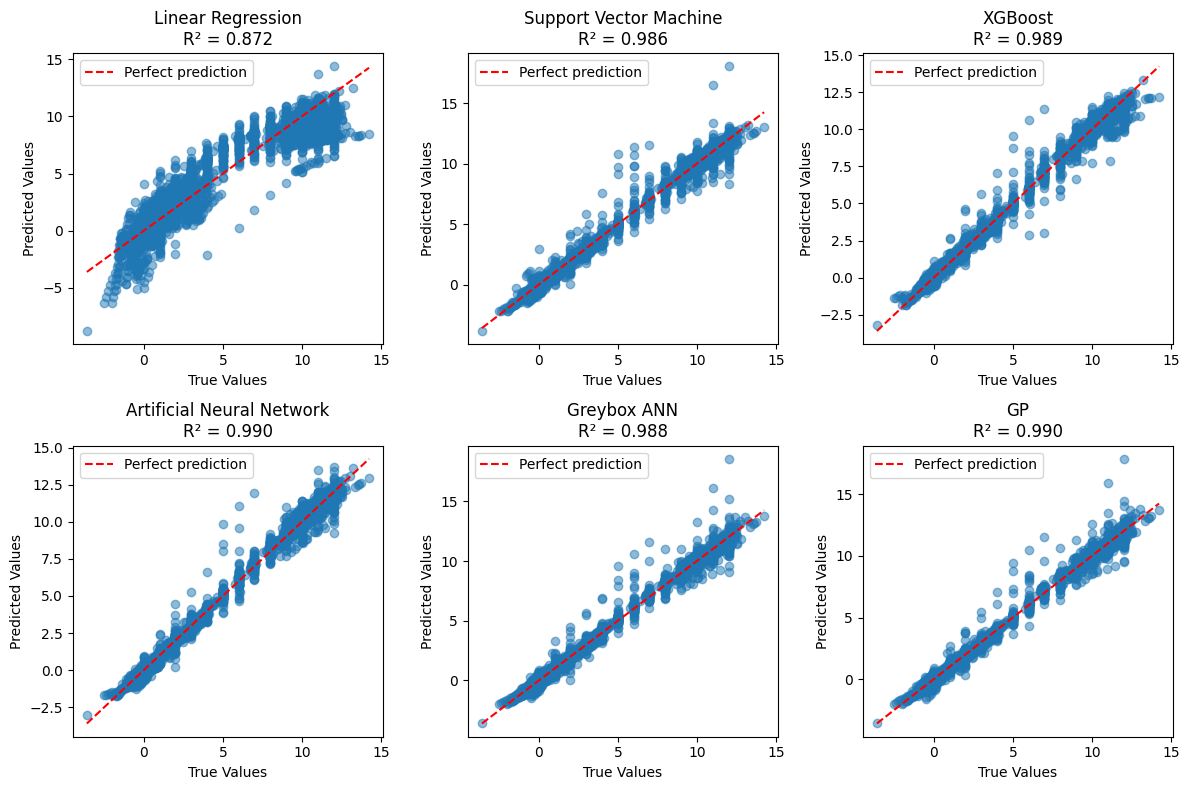

In [1]:
#!/usr/bin/env python
# coding: utf-8
# (c) Charles Le Losq, Clément Ferraina 2023-2025
# see embedded licence file
# gpvisc 0.3

#
# Library Loading
#
import pandas as pd # manipulate dataframes
import matplotlib.pyplot as plt # plotting
import seaborn as sns
import numpy as np

import gpvisc # our library
import joblib # to load models

# scikit-learn utilities
from sklearn.metrics import root_mean_squared_error, median_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import wilcoxon

# deep learning libraries
import torch

# CPU or GPU?
device = gpvisc.get_device()

from typing import List, Tuple, Dict

def prepare_data_for_gp(ds):
    """Prepare training, validation, and test datasets for the GP and greybox ANN models."""
    X_train = torch.FloatTensor(np.concatenate((1000/ds.T_train, ds.P_train/30.0, ds.X_train[:,0:12]), axis=1).copy())
    X_valid = torch.FloatTensor(np.concatenate((1000/ds.T_valid, ds.P_valid/30.0, ds.X_valid[:,0:12]), axis=1).copy())
    X_test = torch.FloatTensor(np.concatenate((1000/ds.T_test, ds.P_test/30.0, ds.X_test[:,0:12]), axis=1).copy())

    Y_train = torch.FloatTensor(ds.y_train.ravel().copy()) / gpvisc.Y_scale()
    Y_valid = torch.FloatTensor(ds.y_valid.ravel().copy()) / gpvisc.Y_scale()
    Y_test = torch.FloatTensor(ds.y_test.ravel().copy()) / gpvisc.Y_scale()

    return X_train, X_valid, X_test, Y_train, Y_valid, Y_test


class ModelEvaluator:
    def __init__(self, y_true: np.ndarray, predictions: Dict[str, np.ndarray]):
        """
        Initialize the model evaluator with true values and predictions from different models.
        
        Args:
            y_true: Ground truth values
            predictions: Dictionary of model predictions with model names as keys
        """
        self.y_true = y_true
        self.predictions = predictions
        self.metrics = {}
        
    def calculate_all_metrics(self) -> Dict[str, Dict[str, float]]:
        """Calculate RMSE, MAE, and R² for all models."""
        for model_name, preds in self.predictions.items():
            self.metrics[model_name] = {
                'rmse': root_mean_squared_error(self.y_true, preds),
                'mae': median_absolute_error(self.y_true, preds),
                'r2': r2_score(self.y_true, preds),
            }
        return self.metrics
    
    def permutation_test(self, model1: str, model2: str, n_permutations: int = 1000) -> Tuple[float, float]:
        """
        Perform permutation test between two models.
        
        Args:
            model1: Name of first model
            model2: Name of second model
            n_permutations: Number of permutations for the test
            
        Returns:
            Tuple of (observed difference, p-value)
        """
        residuals1 = self.y_true - self.predictions[model1]
        residuals2 = self.y_true - self.predictions[model2]
        
        observed_diff = np.median(np.abs(residuals1)) - np.median(np.abs(residuals2))
        combined_residuals = np.vstack([residuals1, residuals2])
        permuted_diffs = []

        for _ in range(n_permutations):
            permuted = np.random.permutation(combined_residuals.flatten())
            perm1, perm2 = permuted[:len(residuals1)], permuted[len(residuals1):]
            perm_diff = np.median(np.abs(perm1)) - np.median(np.abs(perm2))
            permuted_diffs.append(perm_diff)

        p_value = (np.sum(np.abs(permuted_diffs) >= np.abs(observed_diff)) + 1) / (n_permutations + 1)
        return observed_diff, p_value
    
    def wilcoxon_test(self, model1: str, model2: str) -> Tuple[float, float]:
        """
        Perform Wilcoxon test between two models.
        
        Args:
            model1: Name of first model
            model2: Name of second model
            
        Returns:
            Tuple of (statistic, p-value)
        """
        residuals1 = self.y_true - self.predictions[model1]
        residuals2 = self.y_true - self.predictions[model2]
        
        diff_residuals = residuals1 - residuals2
        stat, p_value = wilcoxon(diff_residuals)
        return stat, p_value

    def evaluate_confidence_intervals(self, predictions: np.ndarray, uncertainties: np.ndarray, 
                                   confidence_level: float = 0.95) -> float:
        """
        Evaluate what percentage of true values fall within the confidence intervals.
        
        Args:
            predictions: Model predictions
            uncertainties: Prediction uncertainties (standard errors)
            confidence_level: Desired confidence level (default 0.95 for 95% CI)
        """
        z_score = abs(np.percentile(np.random.standard_normal(10000), 
                                  (1 - confidence_level) * 100 / 2))
        lower_bound = predictions - z_score * uncertainties
        upper_bound = predictions + z_score * uncertainties
        
        within_interval = (self.y_true >= lower_bound) & (self.y_true <= upper_bound)
        return np.mean(within_interval) * 100
    
    def plot_prediction_comparison(self, figsize: Tuple[int, int] = (12, 8)):
        """Create a comparison plot of predictions vs true values for all models."""
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        axes = axes.ravel()
        
        for idx, (model_name, preds) in enumerate(self.predictions.items()):
            ax = axes[idx]
            ax.scatter(self.y_true, preds, alpha=0.5)
            ax.plot([self.y_true.min(), self.y_true.max()], 
                   [self.y_true.min(), self.y_true.max()], 
                   'r--', label='Perfect prediction')
            ax.set_xlabel('True Values')
            ax.set_ylabel('Predicted Values')
            ax.set_title(f'{model_name}\nR² = {self.metrics[model_name]["r2"]:.3f}')
            ax.legend()
        
        plt.tight_layout()
        return fig
    
    def print_summary(self):
        """Print a summary of all metrics for all models."""
        print("\nModel Performance Summary:")
        print("-" * 60)
        headers = ['Model', 'RMSE', 'MAE', 'R²']
        row_format = "{:<20} {:<12} {:<12} {:<12}"
        print(row_format.format(*headers))
        print("-" * 60)
        
        for model_name, metrics in self.metrics.items():
            values = [model_name, 
                     f"{metrics['rmse']:.2f}", 
                     f"{metrics['mae']:.2f}", 
                     f"{metrics['r2']:.3f}"]
            print(row_format.format(*values))

# Load models
clf_linreg = joblib.load('./models/clf_linreg.joblib')
clf_svr = joblib.load('./models/clf_svr.joblib')
clf_nn = joblib.load('./models/clf_nn.joblib')
clf_xgb = joblib.load('./models/clf_xgb.joblib')
gp_model, likelihood = gpvisc.load_gp_model(model_number=1, device=device)

# Load data
print("Loading the viscosity datasets...")
ds = gpvisc.data_loader()

# We prepare data as done for the Grebox ANN and GP models
X_train, X_valid, X_test, Y_train, Y_valid, Y_test = prepare_data_for_gp(ds)

# we glue things together as done during final training
# the Greybox ANN does not really uses the validation dataset but this is not a problem
# it still uses the validation dataset to stop the training when the validation loss does not decrease anymore
# so we consider that the validation dataset affects training metrics
X_train_valid = torch.cat((X_train, X_valid)).clone()
Y_train_valid = torch.cat((Y_train, Y_valid)).clone().ravel()

# predictions using the greybox ANN model
greybox_train_valid_preds = gpvisc.predict(X_train_valid, gp_model, likelihood, model_to_use="ann")
greybox_test_preds = gpvisc.predict(X_test, gp_model, likelihood, model_to_use="ann")

# predictions using the GP, which will refine the greybox ANN predictions
GP_preds_train_valid, _ = gpvisc.predict(X_train_valid, gp_model, likelihood)
GP_preds_test, GP_preds_test_ese = gpvisc.predict(X_test, gp_model, likelihood)

# put back the Y values in numpy array with the good scale
Y_train_valid = (Y_train_valid*gpvisc.Y_scale()).cpu().detach().numpy()
Y_test = (Y_test*gpvisc.Y_scale()).cpu().detach().numpy()

# scaling for the blackbox models
scaler = StandardScaler().fit(ds.TPX_train_valid[:,:14])
ds.TPX_train_valid_scaled = scaler.transform(ds.TPX_train_valid[:,:14])
ds.TPX_test_scaled = scaler.transform(ds.TPX_test[:,:14])

# predictions
predictions_train = {
        'Linear Regression': clf_linreg.predict(ds.TPX_train_valid_scaled).reshape(-1),
        'Support Vector Machine': clf_svr.predict(ds.TPX_train_valid_scaled).reshape(-1),
        'XGBoost': clf_xgb.predict(ds.TPX_train_valid_scaled).reshape(-1),
        'Artificial Neural Network': clf_nn.predict(ds.TPX_train_valid_scaled).reshape(-1),
        'Greybox ANN': greybox_train_valid_preds,
        'GP': GP_preds_train_valid
    
    }

# do the same for the test dataset
predictions_test = {
        'Linear Regression': clf_linreg.predict(ds.TPX_test_scaled).reshape(-1),
        'Support Vector Machine': clf_svr.predict(ds.TPX_test_scaled).reshape(-1),
        'XGBoost': clf_xgb.predict(ds.TPX_test_scaled).reshape(-1),
        'Artificial Neural Network': clf_nn.predict(ds.TPX_test_scaled).reshape(-1),
        'Greybox ANN': greybox_test_preds,
        'GP': GP_preds_test
    }

# do the same for the test* dataset, which excludes SciGlass data
predictions_test_star = {
        'Linear Regression': clf_linreg.predict(ds.TPX_test_scaled).reshape(-1)[ds.Sciglass_test.ravel() == False],
        'Support Vector Machine': clf_svr.predict(ds.TPX_test_scaled).reshape(-1)[ds.Sciglass_test.ravel() == False],
        'XGBoost': clf_xgb.predict(ds.TPX_test_scaled).reshape(-1)[ds.Sciglass_test.ravel() == False],
        'Artificial Neural Network': clf_nn.predict(ds.TPX_test_scaled).reshape(-1)[ds.Sciglass_test.ravel() == False],
        'Greybox ANN': greybox_test_preds[ds.Sciglass_test.ravel() == False],
        'GP': GP_preds_test[ds.Sciglass_test.ravel() == False],
    }
    
# Initialize evaluators and evaluate metrics on different portions of thedataset
print("\nTraining-Validation metrics")
evaluator_train = ModelEvaluator(Y_train_valid, predictions_train)
evaluator_train.calculate_all_metrics()
evaluator_train.print_summary()

print("\nTest metrics")
evaluator_test = ModelEvaluator(Y_test, predictions_test)
evaluator_test.calculate_all_metrics()
evaluator_test.print_summary()

print("\nTest* metrics (SciGlass excluded)")
evaluator_test_star = ModelEvaluator(Y_test[ds.Sciglass_test.ravel() == False], 
                                predictions_test_star)
evaluator_test_star.calculate_all_metrics()
evaluator_test_star.print_summary()

# Evaluate GP confidence intervals
print("\nEvaluation of the GP confidence intervals:")
ci_coverage = evaluator_test.evaluate_confidence_intervals(GP_preds_test, GP_preds_test_ese)
print(f"\nGP Model Confidence Interval Coverage: {ci_coverage:.1f}%")
    
# Perform permutation tests against GP model
print("\nPermutation Tests (comparing against GP model):")
print("-" * 60)
for model_name in predictions_test.keys():
    if model_name != 'GP':
        diff, p_value = evaluator_test.permutation_test(model_name, 'GP')
        print(f"{model_name:20} MAE diff: {diff:>8.3f}, p-value: {p_value:.3f}")
    
# Perform wilcoxon tests against GP model
print("\Wilcoxon Tests (comparing against GP model):")
print("-" * 60)
for model_name in predictions_test.keys():
    if model_name != 'GP':
        diff, p_value = evaluator_test.wilcoxon_test(model_name, 'GP')
        print(f"{model_name:20} stat diff: {diff:>8.3f}, p-value: {p_value:.3f}")
        
# Create comparison plot
fig = evaluator_test.plot_prediction_comparison()
plt.show()

# Test residual histograms

/tmp/ipykernel_3355791/4122392298.py:69: RuntimeWarning: invalid value encountered in divide
  Al_rich = ds.TPX_test[:, al2o3]/(np.sum(ds.TPX_test[:, [al2o3,tio2,sio2]], axis=1)) > 0.3
/tmp/ipykernel_3355791/4122392298.py:74: RuntimeWarning: invalid value encountered in divide
  Alka_rich = np.sum(ds.TPX_test[:, [na2o,k2o]], axis=1)/np.sum(ds.TPX_test[:, [na2o,k2o,cao,mgo]], axis=1) > 0.5
/tmp/ipykernel_3355791/4122392298.py:75: RuntimeWarning: invalid value encountered in divide
  Calc_rich = np.sum(ds.TPX_test[:, [mgo,cao]], axis=1)/np.sum(ds.TPX_test[:, [na2o,k2o,cao,mgo]], axis=1) > 0.5


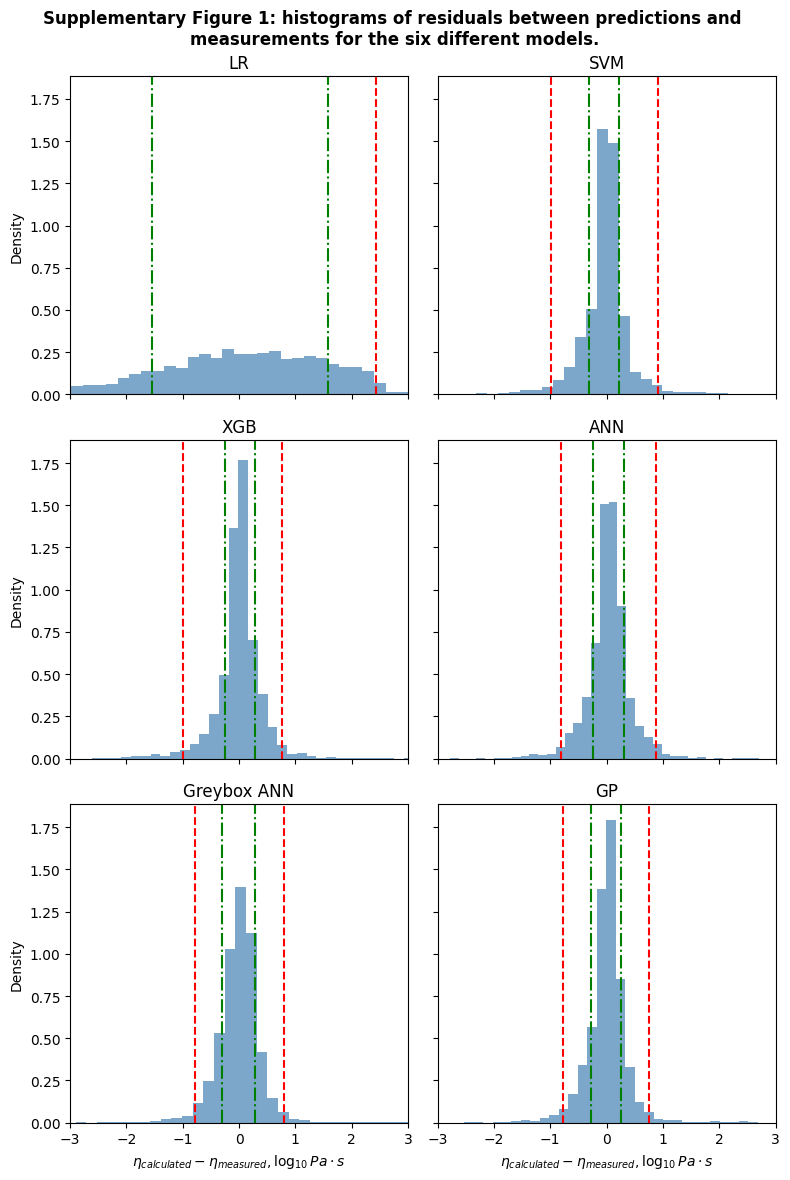

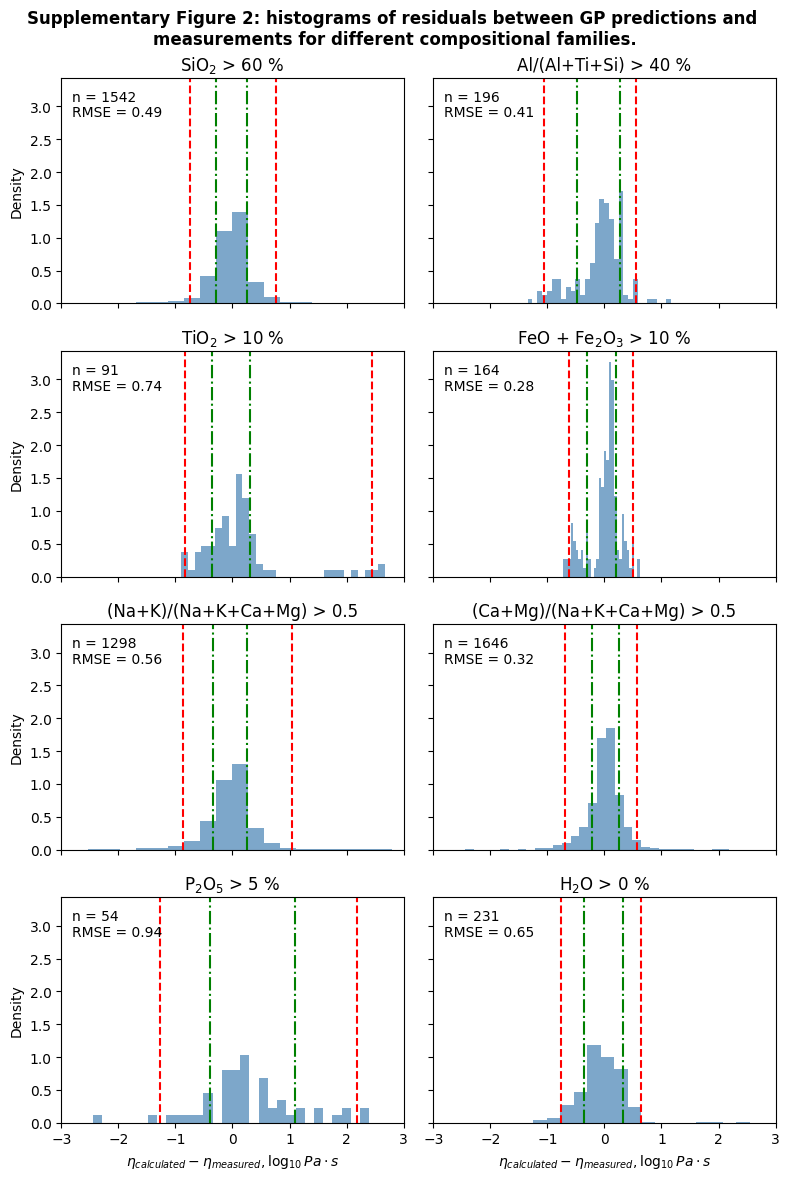

In [41]:
################################################################################
# Plot test residual histograms
################################################################################

# Titles for each subplot
model_names = ['LR', 'SVM', 'XGB', 'ANN', 'Greybox ANN', 'GP']
model_keys = list(predictions_test.keys())

# Create subplots with shared axes
fig, axes = plt.subplots(3, 2, figsize=(8, 12), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten for easier iteration

# Loop through models and plot
for i, ax in enumerate(axes):
    # Calculate deviations
    deviation = predictions_test[model_keys[i]].ravel() - Y_test
    
    # Calculate percentiles
    p2_5 = np.percentile(deviation, 2.5)  # Lower bound for 95%
    p97_5 = np.percentile(deviation, 97.5)  # Upper bound for 95%
    p16 = np.percentile(deviation, 16)  # Lower bound for 68%
    p84 = np.percentile(deviation, 84)  # Upper bound for 68%
    
    # Plot histogram
    ax.hist(deviation, density=True, bins=50, alpha=0.7, color='steelblue')
    
    # Add vertical lines for percentiles
    ax.axvline(p2_5, color='red', linestyle='--', label='2.5th Percentile')
    ax.axvline(p97_5, color='red', linestyle='--', label='97.5th Percentile')
    ax.axvline(p16, color='green', linestyle='-.', label='16th Percentile')
    ax.axvline(p84, color='green', linestyle='-.', label='84th Percentile')
    
    # Customize each subplot
    ax.set_xlim(-3, 3)
    ax.set_title(model_names[i])
    if i % 2 == 0:  # Left column
        ax.set_ylabel('Density')
    if i >= 4:  # Bottom row
        ax.set_xlabel('$\eta_{calculated}-\eta_{measured}, \log_{10} Pa \cdot s$')
    
# Add a single legend for the figure
handles, labels = axes[0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center', ncol=4, fontsize='small', bbox_to_anchor=(0.5, 0.98))

# Improve layout
plt.suptitle("Supplementary Figure 1: histograms of residuals between predictions and \nmeasurements for the six different models.", fontweight='bold')
plt.tight_layout()
plt.savefig("./figures/Supplementary_Figure_1.pdf")

################################################################################
# Plot GP test residual histograms for different compositional families
################################################################################

sio2 = 2
tio2 = 3
al2o3 = 4
feo = 5
fe2o3 = 6
mno = 7
na2o = 8 
k2o = 9
mgo = 10
cao = 11
p2o5 = 12
h2o = 13

Compos_Test = ds.TPX_test[:, 2:]
Si_rich = ds.TPX_test[:, sio2] > 0.6
Al_rich = ds.TPX_test[:, al2o3]/(np.sum(ds.TPX_test[:, [al2o3,tio2,sio2]], axis=1)) > 0.3
Ti_rich = ds.TPX_test[:, tio2] > 0.1
Fe_rich = (ds.TPX_test[:, feo]+ds.TPX_test[:, feo]) > 0.15
P_rich = ds.TPX_test[:, p2o5] > 0.05
H_rich = ds.TPX_test[:, h2o] > 0.0
Alka_rich = np.sum(ds.TPX_test[:, [na2o,k2o]], axis=1)/np.sum(ds.TPX_test[:, [na2o,k2o,cao,mgo]], axis=1) > 0.5
Calc_rich = np.sum(ds.TPX_test[:, [mgo,cao]], axis=1)/np.sum(ds.TPX_test[:, [na2o,k2o,cao,mgo]], axis=1) > 0.5

mask_list = [Si_rich, Al_rich, Ti_rich, Fe_rich, Alka_rich, Calc_rich, P_rich, H_rich]

# Titles for each subplot
name_list = ["SiO$_2$ > 60 %",
             "Al/(Al+Ti+Si) > 40 %",
             "TiO$_2$ > 10 %",
             "FeO + Fe$_2$O$_3$ > 10 %",
             "(Na+K)/(Na+K+Ca+Mg) > 0.5",
             "(Ca+Mg)/(Na+K+Ca+Mg) > 0.5",
             "P$_2$O$_5$ > 5 %",
             "H$_2$O > 0 %"
             ]

# Create subplots with shared axes
fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharex=True, sharey=True)
axes = axes.flatten()  # Flatten for easier iteration

for i, ax in enumerate(axes):
    
    # Calculate deviations
    deviation = (GP_preds_test[mask_list[i]].ravel() - Y_test[mask_list[i]])
    
    # add number of data points
    number_points = len(deviation)

    # Calculate percentiles
    p2_5 = np.percentile(deviation, 2.5)  # Lower bound for 95%
    p97_5 = np.percentile(deviation, 97.5)  # Upper bound for 95%
    p16 = np.percentile(deviation, 16)  # Lower bound for 68%
    p84 = np.percentile(deviation, 84)  # Upper bound for 68%
    rmse = np.sqrt(np.mean(deviation**2))
    
    # Plot histogram
    ax.hist(deviation, density=True, bins=30, alpha=0.7, color='steelblue')
    
    # Add vertical lines for percentiles
    ax.axvline(p2_5, color='red', linestyle='--', label='$2.5^{th}$ per.')
    ax.axvline(p97_5, color='red', linestyle='--', label='$97.5^{th}$ per.')
    ax.axvline(p16, color='green', linestyle='-.', label='$16^{th}$ per.')
    ax.axvline(p84, color='green', linestyle='-.', label='$84^{th}$ per.')
    
    # Customize subplot
    ax.set_xlim(-3, 3)
    ax.set_title(name_list[i])
    ax.annotate("n = {}".format(number_points),
                 xy= (0.03,0.9),
                 xycoords="axes fraction")
    ax.annotate("RMSE = {:.2f}".format(rmse),
                 xy= (0.03,0.83),
                 xycoords="axes fraction")
    
    if i % 2 == 0:  # Left column
        ax.set_ylabel('Density')
    if i >= 6:  # Bottom row
        ax.set_xlabel('$\eta_{calculated}-\eta_{measured}, \log_{10} Pa \cdot s$')

plt.suptitle("Supplementary Figure 2: histograms of residuals between GP predictions and \nmeasurements for different compositional families.", fontweight='bold')
plt.tight_layout()
plt.savefig("./figures/Supplementary_Figure_2.pdf")


# Local RMSE versus Local data density on the Test data subset

We use a KDTree to calcule the local data density (over the melt composition, within a 5 mol% radius)

Pearson Correlation: -0.053, p-value: 0.004


/tmp/ipykernel_3355791/1622053586.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x="Data Density Bin", y="Local RMSE", inner="box", palette="Set2")


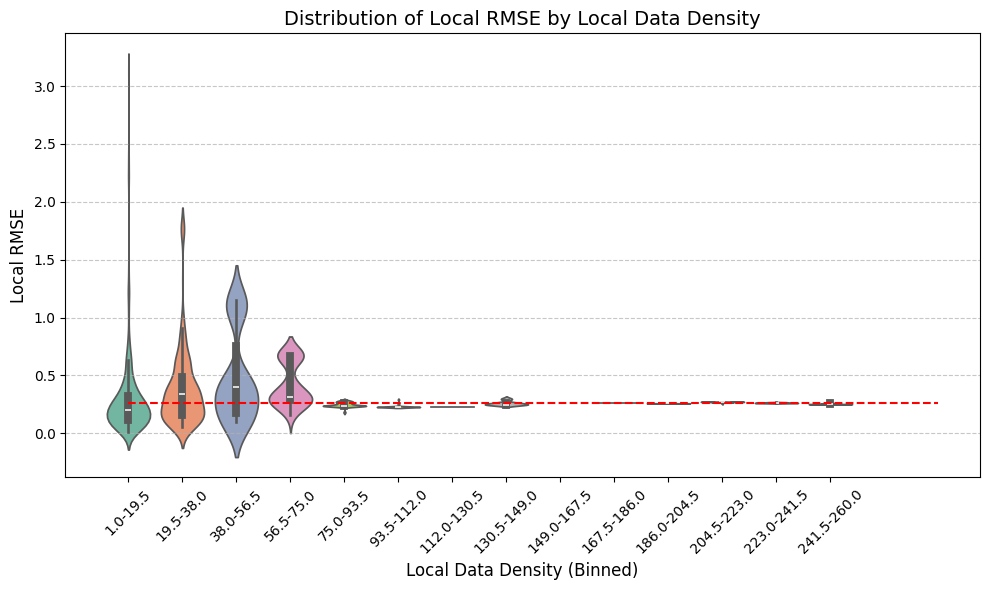

In [ ]:
from sklearn.neighbors import KDTree

radius = 0.05  # Define a suitable radius for "local region"
tree = KDTree(X_test[:,2:]) # we only search over the compositional space

# Local data density: count neighbors within the radius for each test point
local_density = np.array([len(tree.query_radius([x], r=radius)[0]) for x in X_test[:,2:]])

local_rmse = []
for i, x in enumerate(X_test[:,2:]):
    neighbors_idx = tree.query_radius([x], r=radius)[0]
    if len(neighbors_idx) > 0:
        # The GP_preds_test contains the Y predicted values of the test dataset
        # I would like to get the predictions of the neighbors
        local_test_preds = GP_preds_test[neighbors_idx]
        # and the local true values
        local_test_true = Y_test[neighbors_idx]
        # and we calculate RMSE between them
        rmse = root_mean_squared_error(local_test_true, local_test_preds)
        local_rmse.append(rmse)
    else:
        local_rmse.append(np.nan)  # No neighbors in the radius

local_rmse = np.array(local_rmse)

# Pearson Correlation
from scipy.stats import pearsonr
pearson_corr, pearson_p = pearsonr(local_density, local_rmse)
print(f"Pearson Correlation: {pearson_corr:.3f}, p-value: {pearson_p:.3f}")

#
# Make a plot
#
# Bin local data density into discrete categories for grouping
bins = np.linspace(min(local_density), max(local_density), 15)  # Adjust bin count as needed
bin_labels = [f"{round(bins[i], 2)}-{round(bins[i+1], 2)}" for i in range(len(bins)-1)]
binned_density = pd.cut(local_density, bins, labels=bin_labels)

# Create a DataFrame for easy plotting
plot_data = pd.DataFrame({
    "Local RMSE": local_rmse,
    "Data Density Bin": binned_density
})

# Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, 
               x="Data Density Bin", y="Local RMSE", 
               inner="box", palette="Set2")

plt.plot([0,15], [0.26, 0.26], "r--")

# Add plot labels and titles
plt.xlabel("Local Data Density (Binned)", fontsize=12)
plt.ylabel("Local RMSE", fontsize=12)
plt.title("Local RMSE versus Local Data Density", fontsize=14)
plt.xticks(rotation=45)  # Rotate x-axis labels if needed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Compare Greybox and GP predictions at very high temperature for water-bearing melts.

Converting weight percent composition to mole fraction...
Converting weight percent composition to mole fraction...
Converting weight percent composition to mole fraction...


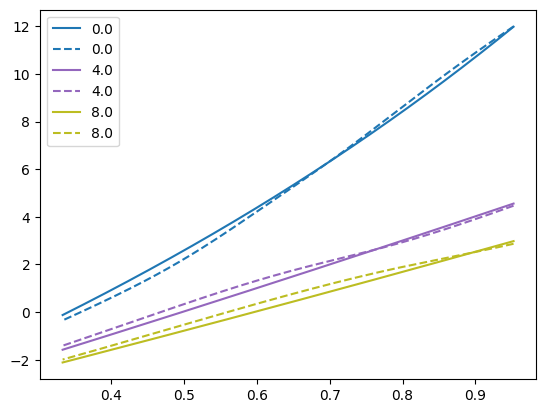

In [40]:
plt.figure()
for h2o_content in [0.0, 4.0, 8.0]:
    # add SiO2 curve
    db_in = gpvisc.generate_query_single(sio2=50.,
                                     tio2=0.0,
                                     al2o3=13.3,
                                     feo=0.9,
                                     mno=0.02,
                                     mgo=0.05,
                                     cao=0.41,
                                     na2o=3.43,
                                     k2o=5.36,
                                     h2o=h2o_content,
                                    composition_mole = False,
                                    T_init = 1050.0, T_final= 3000.0,
                                    P_init = 0.0, P_final = 0.0,
                                    nb_values = 300,
                                    )
    
    # calculate the input for the GP
    X_in = gpvisc.scale_for_gaussianprocess(db_in["T"], db_in["P"], db_in)
    sio2_visco_mean2, visco_std = gpvisc.predict(X_in, gp_model, likelihood)
    sio2_visco_mean = gp_model.mean_f(torch.FloatTensor(X_in)).detach().numpy()*gpvisc.Y_scale()

    plt.plot(1000/db_in["T"], sio2_visco_mean, label=str(h2o_content), color="C"+str(int(h2o_content)))#surface_temperat
    plt.plot(1000/db_in["T"], sio2_visco_mean2, linestyle = "--", label=str(h2o_content), color="C"+str(int(h2o_content)))#surface_temperat
plt.legend()